In [ ]:
# Temperature Prediction Model (Kolkata)

This notebook builds a machine learning model to predict:
- Maximum Temperature
- Minimum Temperature
- Median Temperature

### Dataset
- Source: Meteostat (processed daily data)
- Location: Kolkata
- Features include:
  - Temperature statistics
  - Humidity
  - Pressure
  - Rainfall
  - Wind speed
  - Cloud cover

### Objective
Predict next day's temperature values using historical weather data.

In [20]:
## Data Loading and Preprocessing

# We load the cleaned daily weather dataset and convert the date column into datetime format for time-series operations.

import pandas as pd
import numpy as np

# Load dataset
daily = pd.read_csv("kolkata_daily_data_new.csv")

# Convert date column to datetime format
daily['date'] = pd.to_datetime(daily['date'])

daily = daily.sort_values('date')

In [ ]:
## Feature Engineering

# We create:
# - Lag features (previous day values)
# - Rolling mean features (7-day trends)

# These help the model capture temporal dependencies in weather patterns.

In [2]:
lag_features = [
    'temp_max',
    'temp_min',
    'temp_median',
    'humidity_mean',
    'pressure_mean',
    'rain_total',
    'wind_mean',
    'cloud_mean'
]

for col in lag_features:
    for lag in range(1, 8):
        daily[f'{col}_lag{lag}'] = daily[col].shift(lag)

In [21]:
# Creating rolling mean features (7-day window)
for col in ['temp_max', 'temp_min', 'temp_median']:
    daily[f'{col}_roll7_mean'] = daily[col].rolling(7).mean()
    daily[f'{col}_roll7_std'] = daily[col].rolling(7).std()

daily['humidity_roll7_mean'] = daily['humidity_mean'].rolling(7).mean()
daily['rain_roll7_sum'] = daily['rain_total'].rolling(7).sum()

In [ ]:
## Target Variable Creation

# We shift temperature values by 1 day to predict the next day's temperature.

In [22]:
targets = ['temp_max', 'temp_min', 'temp_median']

# Shift target variables by 1 day (next day prediction)
for col in targets:
    daily[f'{col}_target'] = daily[col].shift(-1)

daily = daily.dropna().reset_index(drop=True)

In [ ]:
## Train-Test Split

# We split the dataset based on time:
# - Training: Before 2022
# - Testing: 2022 onwards

# This ensures no data leakage in time-series prediction.

In [23]:
# Time-based split (important for time series)
train = daily[daily['date'] < '2022-01-01']
test  = daily[daily['date'] >= '2022-01-01']

In [ ]:
## Feature Selection

# We exclude:
# - Date column
# - Target variables

# Remaining columns are used as input features.

In [8]:
feature_cols = [col for col in daily.columns if 
                col not in ['date',
                            'temp_max','temp_min','temp_median',
                            'temp_max_target','temp_min_target','temp_median_target']]

X_train = train[feature_cols]
Y_train = train[['temp_max_target','temp_min_target','temp_median_target']]

X_test = test[feature_cols]
Y_test = test[['temp_max_target','temp_min_target','temp_median_target']]

In [ ]:
## Model Training

# We use:
# - XGBoost Regressor
# - MultiOutputRegressor (to predict multiple targets)

# This allows simultaneous prediction of:
# - Temp max
# - Temp min
# - Temp median

In [24]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# Initialize XGBoost model
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42
)

# MultiOutputRegressor allows multiple outputs
model = MultiOutputRegressor(xgb)
model.fit(X_train, Y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None


In [ ]:
## Model Evaluation

# We evaluate model performance using:
# - Mean Absolute Error (MAE)

# Lower MAE indicates better prediction accuracy.

In [10]:
from sklearn.metrics import mean_absolute_error

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print("Train MAE temp_max:",
      mean_absolute_error(Y_train.iloc[:,0], train_preds[:,0]))

print("Test MAE temp_max:",
      mean_absolute_error(Y_test.iloc[:,0], test_preds[:,0]))

Train MAE temp_max: 0.6030589441958459
Test MAE temp_max: 1.1480320458642124


In [ ]:
## Visualization

# We compare:
# - Actual vs Predicted values
# - Residual errors

# This helps understand model performance visually.

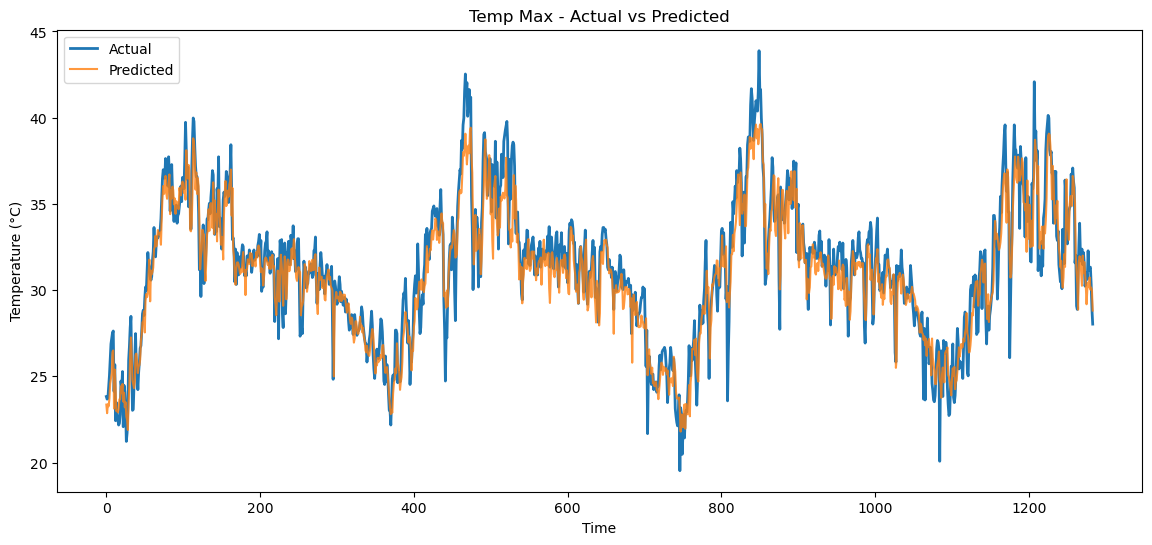

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(Y_test.iloc[:,0].values, label="Actual", linewidth=2)
plt.plot(test_preds[:,0], label="Predicted", alpha=0.8)
plt.legend()
plt.title("Temp Max - Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

In [ ]:
## Error Analysis

# We analyze:
# - Prediction errors
# - High-error cases

# This helps identify model weaknesses.

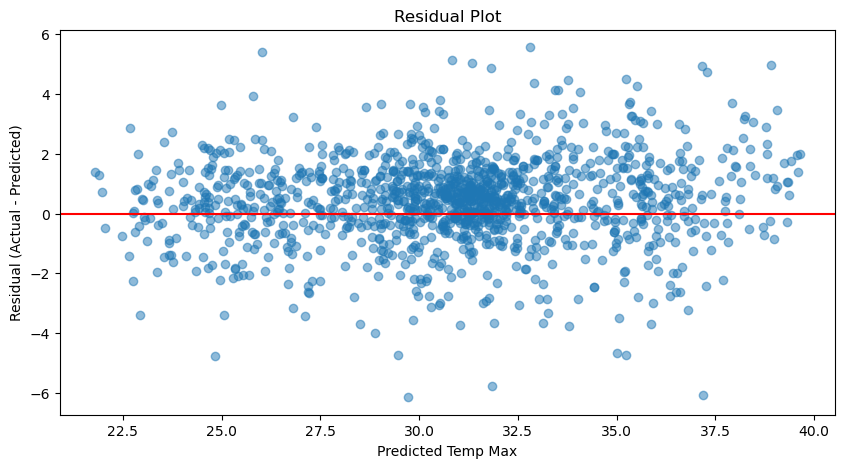

In [12]:
residuals = Y_test.iloc[:,0].values - test_preds[:,0]

plt.figure(figsize=(10,5))
plt.scatter(test_preds[:,0], residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted Temp Max")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

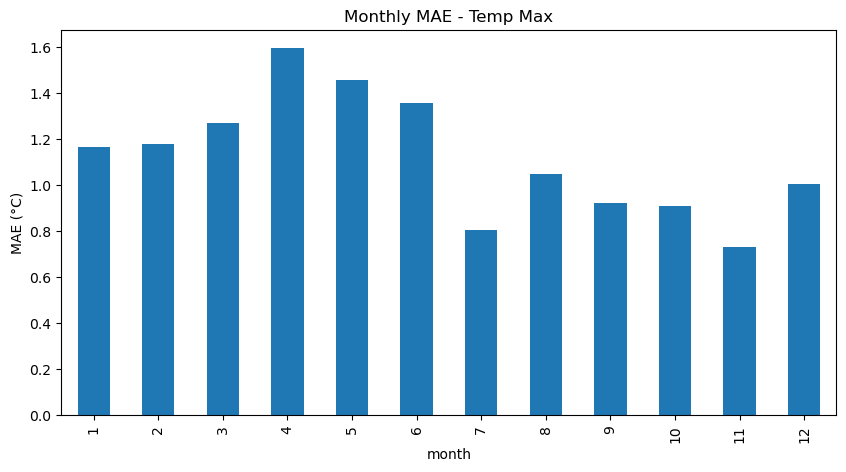

In [13]:
test_copy = test.copy()
test_copy['pred'] = test_preds[:,0]
test_copy['error'] = abs(test_copy['temp_max_target'] - test_copy['pred'])
test_copy['month'] = test_copy['date'].dt.month

monthly_mae = test_copy.groupby('month')['error'].mean()

plt.figure(figsize=(10,5))
monthly_mae.plot(kind='bar')
plt.title("Monthly MAE - Temp Max")
plt.ylabel("MAE (°C)")
plt.show()

In [ ]:
## Bias Analysis

# Bias shows whether the model consistently:
# - Overpredicts or
# - Underpredicts

# Ideal bias ≈ 0

In [14]:
bias = np.mean(Y_test.values - test_preds, axis=0)

print("Temp Max Bias:", bias[0])
print("Temp Min Bias:", bias[1])
print("Temp Median Bias:", bias[2])

Temp Max Bias: 0.4220263789214611
Temp Min Bias: 0.06764547649067397
Temp Median Bias: 0.09560578751446974


In [15]:
# Load CSV
X_input_df = pd.read_csv('X_input.csv')

In [ ]:
## Prediction on New Data

# We test the model on new input data to simulate real-world usage.

In [16]:
X_input = X_input_df.values  # convert to numpy array if your model needs it
y_pred = model.predict(X_input)
print("Next day's prediction:", y_pred)

Next day's prediction: [[31.86983  21.66029  25.641191]]


In [ ]:
## Model Saving

# The trained model is saved using joblib for deployment in the Flask API.

In [25]:
import joblib

# Save trained model
joblib.dump(model, 'temp_model.pkl')

['temp_model.pkl']

In [ ]:
## Conclusion

- Successfully built a multi-output temperature prediction model
- Captured temporal trends using lag and rolling features
- Model is ready for deployment via Flask API